In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [ ]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Shape X_test:", X_test.shape)
print("Shape y_test:", y_test.shape)

Shape X_test: (9043, 51)
Shape y_test: (9043,)


In [5]:
log_model = joblib.load("../models/logistic_regression/logistic_regression.pkl")
rf_model  = joblib.load("../models/random_forest/random_forest.pkl")
svm_model = joblib.load("../models/svm/svm_model.pkl")
xgb_model = joblib.load("../models/xgboost/xgb_baseline.pkl")

print("Modelos base cargados correctamente")

Modelos base cargados correctamente


In [6]:
def evaluate_model(model, X, y):
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
    else:
        y_prob = None

    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1-score": f1_score(y, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, y_prob) if y_prob is not None else np.nan
    }

    return metrics, y_pred, y_prob

In [10]:
results = {}

results["Logistic Regression"], y_pred_log, y_prob_log = evaluate_model(log_model, X_test, y_test)
results["Random Forest"], y_pred_rf, y_prob_rf = evaluate_model(rf_model, X_test, y_test)
results["SVM"], y_pred_svm, y_prob_svm = evaluate_model(svm_model, X_test, y_test)
results["XGBoost"], y_pred_xgb, y_prob_xgb = evaluate_model(xgb_model["model"], X_test, y_test)

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="F1-score", ascending=False)

results_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC
XGBoost,0.891408,0.568592,0.297732,0.390819,0.791744
Random Forest,0.884220,0.508346,0.316635,0.390215,0.783327
Logistic Regression,0.745660,0.260232,0.637051,0.369518,0.767464
SVM,0.842641,0.304394,0.268431,0.285284,0.650741


In [12]:
display(results_df.style.background_gradient(cmap="Blues"))

,Accuracy,Precision,Recall,F1-score,ROC-AUC
XGBoost,0.891408,0.568592,0.297732,0.390819,0.791744
Random Forest,0.884220,0.508346,0.316635,0.390215,0.783327
Logistic Regression,0.745660,0.260232,0.637051,0.369518,0.767464
SVM,0.842641,0.304394,0.268431,0.285284,0.650741


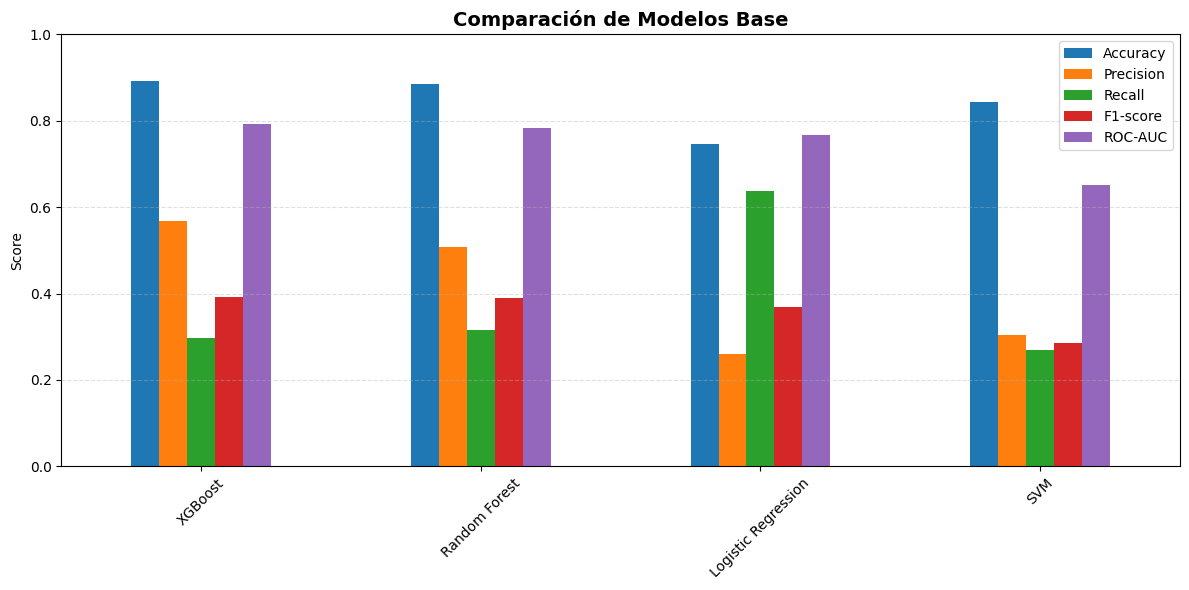

In [13]:
results_df.plot(kind="bar", figsize=(12, 6))
plt.title("Comparación de Modelos Base", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

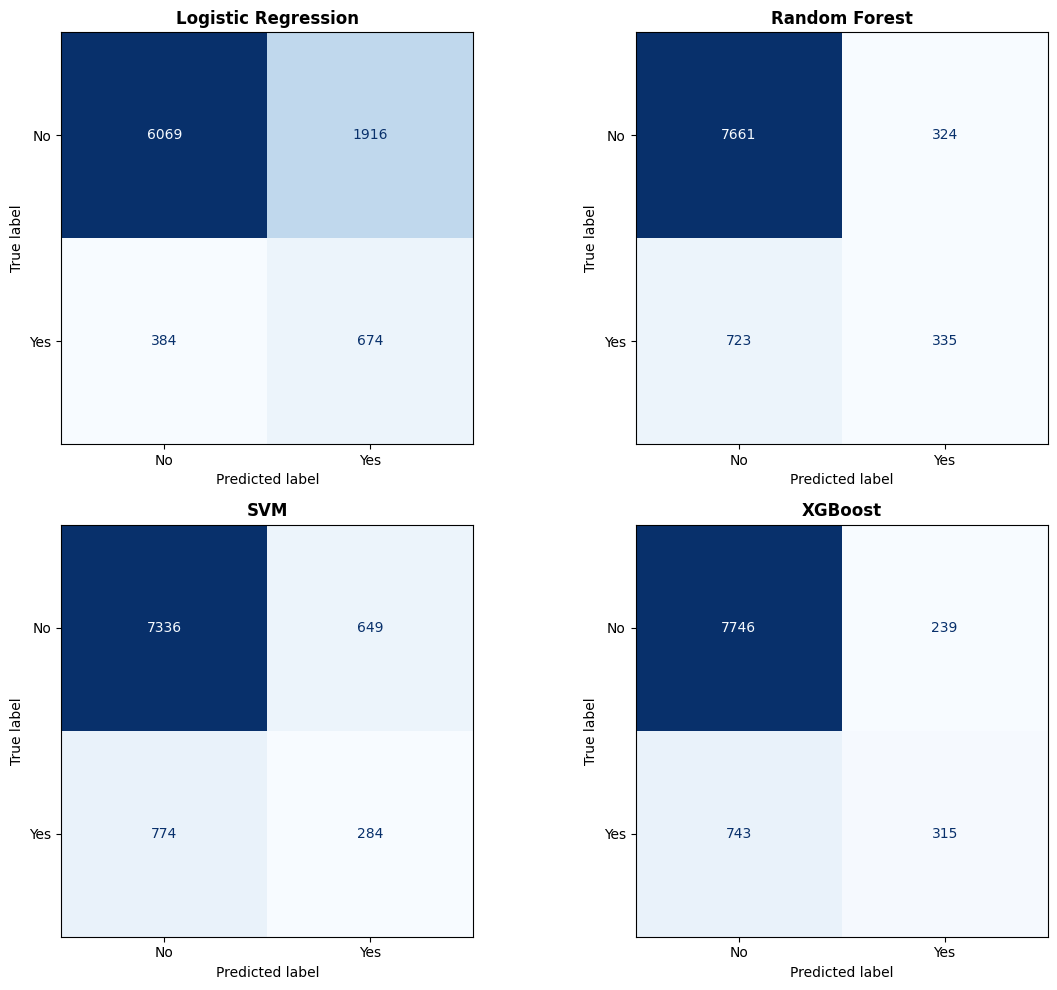

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_preds = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
}

for ax, (name, y_pred) in zip(axes.flat, models_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontweight="bold")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

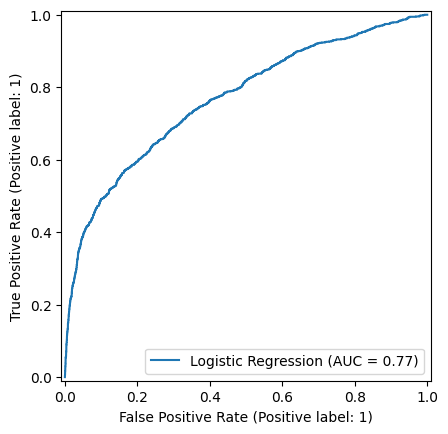

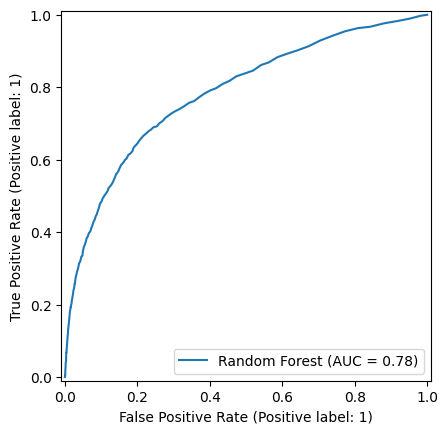

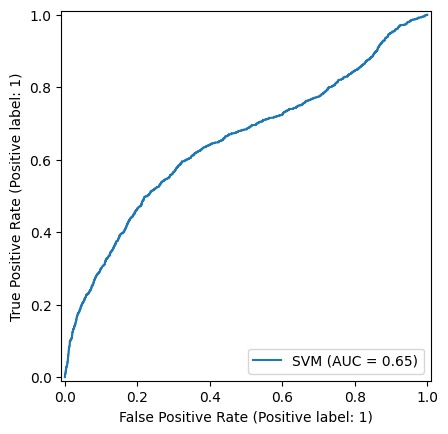

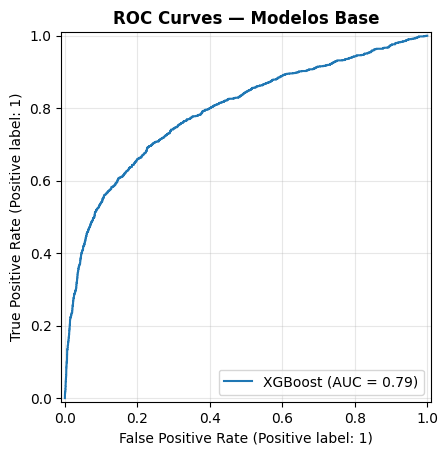

In [15]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_log, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, y_prob_svm, name="SVM")
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost")

plt.title("ROC Curves — Modelos Base", fontweight="bold")
plt.grid(alpha=0.3)
plt.show()

In [17]:
results_df.to_csv("../data/db/model_comparison_base.csv", index=True)
print(" Resultados guardados en ../data/db/model_comparison_base.csv")

 Resultados guardados en ../data/db/model_comparison_base.csv


## Conclusión — Comparación de Modelos Base

Se compararon cuatro modelos base de clasificación: Logistic Regression, Random Forest, SVM y XGBoost.

El objetivo de esta primera comparación es evaluar el rendimiento inicial de cada familia de modelos antes de aplicar optimización de hiperparámetros.

Las métricas más relevantes para este problema son F1-score y ROC-AUC, debido al desbalance de clases existente en la variable objetivo.

A partir de estos resultados, se procederá a comparar las versiones optimizadas de los modelos para seleccionar el modelo final del proyecto.